โค๊ดคำนวณค่าเฉลี่ยและส่วนเบี่บงเบนมาตรฐานของ Intensity ของทุกไฟล์ในโฟลเดอร์ NdatasetCSV

In [1]:
import os
import pandas as pd

# Specify the folder path
folder_path = "PdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty lists to store the calculated statistics
average_intensity_values = []
std_dev_intensity_values = []

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Append the calculated statistics to the lists
        average_intensity_values.append(mean_intensity)
        std_dev_intensity_values.append(std_dev_intensity)
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Combine the calculated statistics from all files into one DataFrame
average_intensity_df = pd.concat(average_intensity_values, axis=1)
std_dev_intensity_df = pd.concat(std_dev_intensity_values, axis=1)

# Rename columns to indicate file names
average_intensity_df.columns = csv_files
std_dev_intensity_df.columns = csv_files

# Sort the DataFrame columns by file names
average_intensity_df = average_intensity_df.sort_index(axis=1)
std_dev_intensity_df = std_dev_intensity_df.sort_index(axis=1)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)


Average Intensity Values:
               BG_0.csv  BG_1.csv  BG_rbru0.csv  BG_rbru1.csv  P100_A.csv  \
Order Color                                                                 
1     Black    5.250000      5.50      4.750000          5.00        5.25   
      Blue   238.750000    239.50    236.250000        240.00       68.25   
      Green  373.000000    370.50    368.500000        378.00       50.00   
      Red    311.750000    311.00    304.500000        305.75       20.75   
      White  863.500000    869.00    857.000000        869.00      128.75   
...                 ...       ...           ...           ...         ...   
24    Black    5.333333      5.00      5.333333          5.00        5.50   
      Blue   237.750000    239.25    236.500000        239.75       71.00   
      Green  372.750000    371.25    371.000000        374.00       51.50   
      Red    311.250000    311.75    304.250000        304.75       22.25   
      White  865.500000    865.75    857.500000   

บันทึกไฟล์รวมข้อมูล ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตราฐานของไฟล์ในโฟลเดอร์  PdatasetCSV  บันทึกเป็นชื่อ  P_Mean.csv  และ N_StdDeV.csv  ในโฟลเดอร์ StandardData

In [2]:
import os
import pandas as pd

# Specify the folder path
folder_path = "PdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "P_Mean.csv"
output_stddev_filename = "P_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             P4_R.csv  P60_R.csv   P80_W.csv  P40_W.csv  P40_A.csv  \
Order Color                                                          
1     Black      5.75       6.75    5.750000       6.50       5.25   
      Blue     128.00     126.50  333.750000     271.25      98.00   
      Green    142.75     123.25  532.750000     349.75      82.50   
      Red       78.50      54.00  353.500000     284.75      30.25   
      White    362.25     312.50  962.500000     841.25     198.25   
...               ...        ...         ...        ...        ...   
24    Black      5.00       6.25    5.666667       6.50       5.00   
      Blue     129.25     126.50  332.750000     273.50      97.75   
      Green    140.50     119.50  535.250000     353.50      83.75   
      Red       76.50      53.75  356.500000     286.00      30.00   
      White    347.25     299.25  961.250000     847.00     199.00   

               P2_B.csv  P80_WR.csv  P80_A.csv  P100_blank.csv 

# ปรับแต่งหัวตาราง

In [3]:
import pandas as pd

# Function to remove ".csv" from column names and save the modified DataFrame
def remove_csv_extension_and_save(filename):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove the ".csv" from column names
    df.columns = [col.replace('.csv', '') for col in df.columns]

    # Save the modified DataFrame back to the original file
    df.to_csv(filename, index=False)

# List of files to process
file_list = ["StandardData/P_mean.csv", "StandardData/P_stddev.csv"]

# Process each file
for file in file_list:
    remove_csv_extension_and_save(file)
    print(f"Updated {file} with modified column names.")


Updated StandardData/P_mean.csv with modified column names.
Updated StandardData/P_stddev.csv with modified column names.


เปิดไฟล์ N_mean.csv เพื่อดูข้อมูล

In [4]:
import pandas as pd

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_mean.csv")

# Display the DataFrame
print(df)


     Order  Color    P4_R   P60_R       P80_W   P40_W   P40_A        P2_B  \
0        1  Black    5.75    6.75    5.750000    6.50    5.25    8.000000   
1        1   Blue  128.00  126.50  333.750000  271.25   98.00  145.000000   
2        1  Green  142.75  123.25  532.750000  349.75   82.50  161.333333   
3        1    Red   78.50   54.00  353.500000  284.75   30.25   90.333333   
4        1  White  362.25  312.50  962.500000  841.25  198.25  369.000000   
..     ...    ...     ...     ...         ...     ...     ...         ...   
115     24  Black    5.00    6.25    5.666667    6.50    5.00    7.666667   
116     24   Blue  129.25  126.50  332.750000  273.50   97.75  143.666667   
117     24  Green  140.50  119.50  535.250000  353.50   83.75  157.666667   
118     24    Red   76.50   53.75  356.500000  286.00   30.00   90.333333   
119     24  White  347.25  299.25  961.250000  847.00  199.00  371.000000   

         P80_WR   P80_A  ...  P40_WR  P100_R   P10_B  P100_NoR   P6_WR  \
0

In [5]:
import pandas as pd
import os

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_mean.csv")

# Calculate the average of the columns following the "Color" column
# Group the data by the "Color" column and calculate the mean
average_by_color = df.groupby("Color").mean()

# Display the result
print("Average by Color:")
print(average_by_color)

# Define the output file path
output_folder = "StandardData"
output_filename = "P_all_Mean.csv"
output_path = os.path.join(output_folder, output_filename)

# Check if the file "N_all_Mean.csv" already exists
if os.path.exists(output_path):
    print(f"'{output_filename}' already exists. Overwriting the file.")

# Save the DataFrame to a CSV file
average_by_color.to_csv(output_path)

print(f"Data saved to '{output_path}' as 'P_all_Mean.csv'.")


Average by Color:
       Order        P4_R       P60_R       P80_W       P40_W       P40_A  \
Color                                                                      
Black   12.5    5.666667    6.531250    5.798611    6.864583    5.593750   
Blue    12.5  128.427083  127.145833  333.250000  270.312500   97.895833   
Green   12.5  142.333333  120.239583  535.968750  350.822917   83.250000   
Red     12.5   78.187500   54.677083  354.802083  286.562500   30.833333   
White   12.5  354.552083  304.635417  962.677083  835.604167  199.406250   

             P2_B      P80_WR       P80_A  P100_blank  ...      P40_WR  \
Color                                                  ...               
Black    7.972222    5.611111    5.635417    7.833333  ...    6.052083   
Blue   144.222222  296.239583   70.760417  241.364583  ...  249.239583   
Green  158.166667  453.593750   51.104167  328.958333  ...  315.958333   
Red     90.125000  307.239583   23.364583  291.010417  ...  269.906250   
White

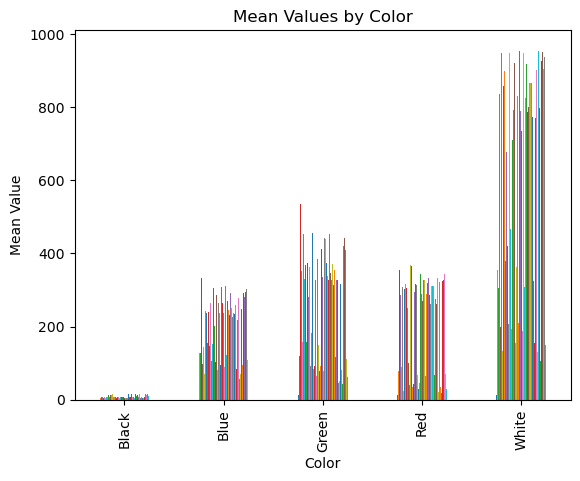

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Plot a bar chart with "Color" on the x-axis and the mean values on the y-axis
df.plot(x="Color", kind="bar", legend=None)

# Set labels and title
plt.xlabel("Color")
plt.ylabel("Mean Value")
plt.title("Mean Values by Color")

# Show the plot
plt.show()


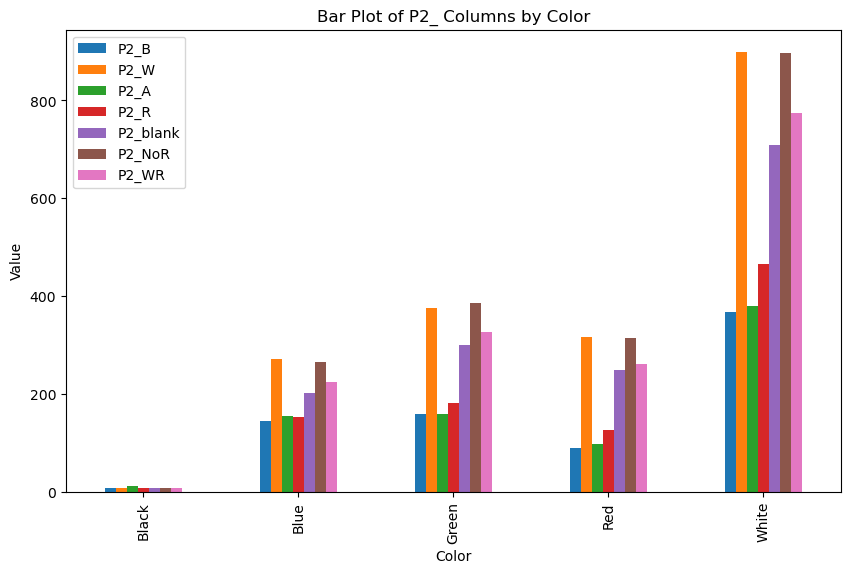

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Filter columns that start with "N2_"
n2_columns = [col for col in df.columns if col.startswith("P2_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n2_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of P2_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()



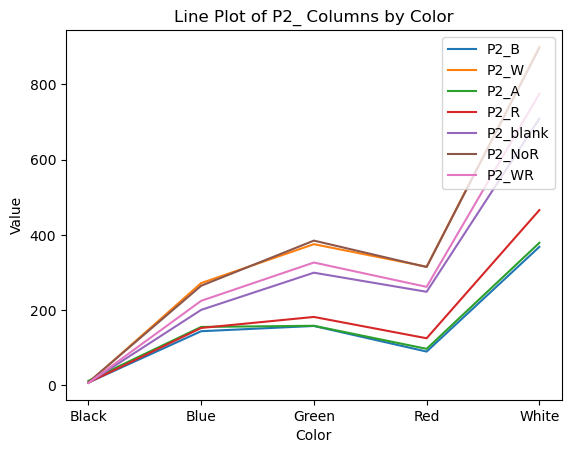

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Filter the columns starting with "N2_"
n2_columns = [col for col in df.columns if col.startswith("P2_")]

# Set "Color" column as the x-axis
x = df["Color"]

# Plot each "N2_" column as a separate line
for col in n2_columns:
    y = df[col]
    plt.plot(x, y, label=col)

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of P2_ Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


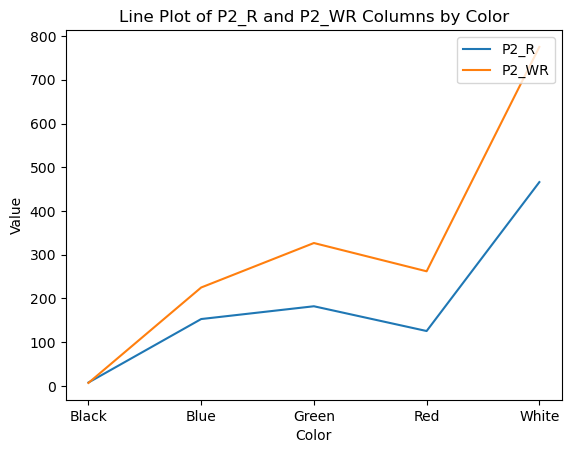

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Set "Color" column as the x-axis
x = df["Color"]

# Select the "N2_R" and "N2_WR" columns as the y-axis
y1 = df["P2_R"]
y2 = df["P2_WR"]

# Plot the "N2_R" and "N2_WR" columns as separate lines
plt.plot(x, y1, label="P2_R")
plt.plot(x, y2, label="P2_WR")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of P2_R and P2_WR Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


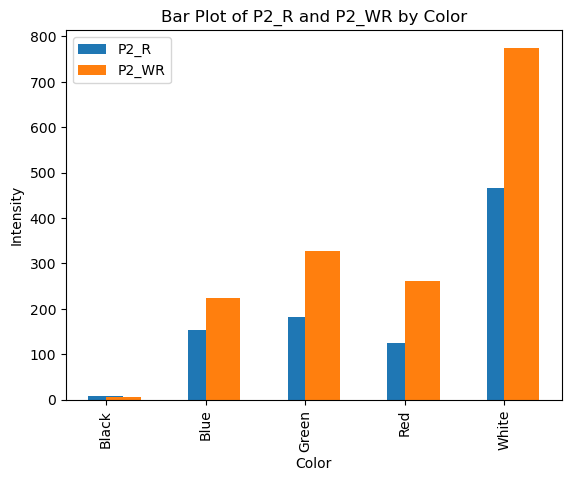

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "P2_R", "P2_WR"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["P2_R"]
y2 = df["P2_WR"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="P2_R", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="P2_WR", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of P2_R and P2_WR by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



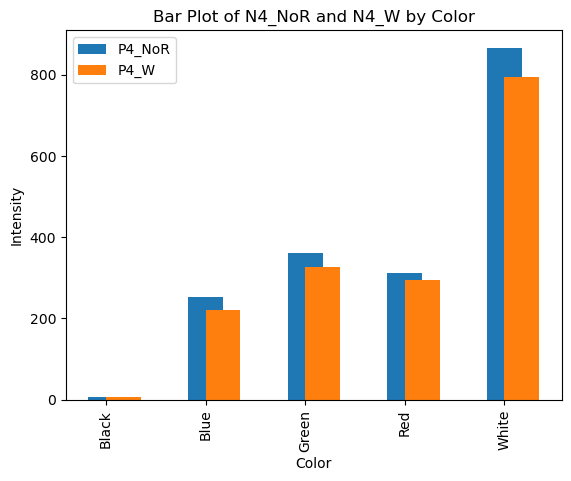

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "P4_NoR", "P4_W"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "P2_R" and "N2_WR" as the y-axis
y1 = df["P4_NoR"]
y2 = df["P4_W"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="P4_NoR", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="P4_W", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_NoR and N4_W by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



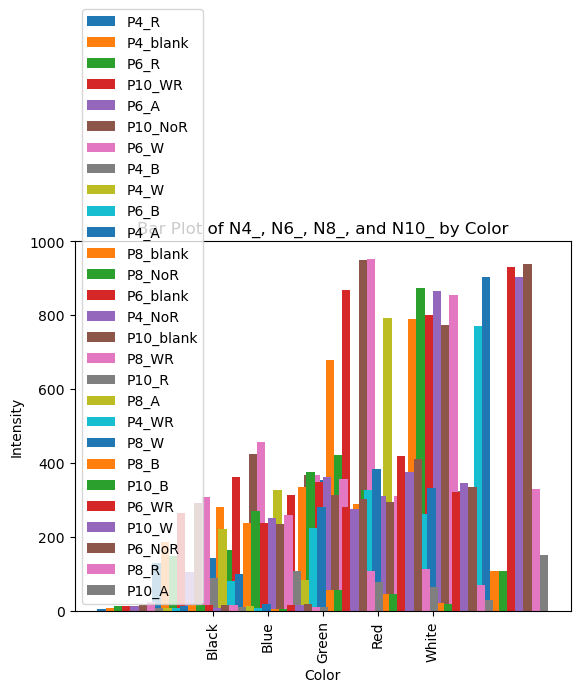

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Select the columns "Color," "N4_NoR," "N4_W," "N6_NoR," "N6_W," "N8_NoR," "N8_W," "N10_NoR," and "N10_W"
selected_columns = [col for col in df.columns if col.startswith("P4_") or col.startswith("P6_") or col.startswith("P8_") or col.startswith("P10_")]
df = df[["Color"] + selected_columns]

# Set "Color" column as the x-axis
x = df["Color"]

# Create a list of y-values for the selected columns
y_values = [df[col] for col in selected_columns]

# Define the width of the bars
bar_width = 0.15

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the values as side-by-side bars
for i, y in enumerate(y_values):
    plt.bar([x + i * bar_width for x in x_indexes], y, width=bar_width, label=selected_columns[i])

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_, N6_, N8_, and N10_ by Color")
plt.xticks([x + bar_width * (len(selected_columns) - 1) / 2 for x in x_indexes], x, rotation=90)
plt.legend()

# Show the plot
plt.show()


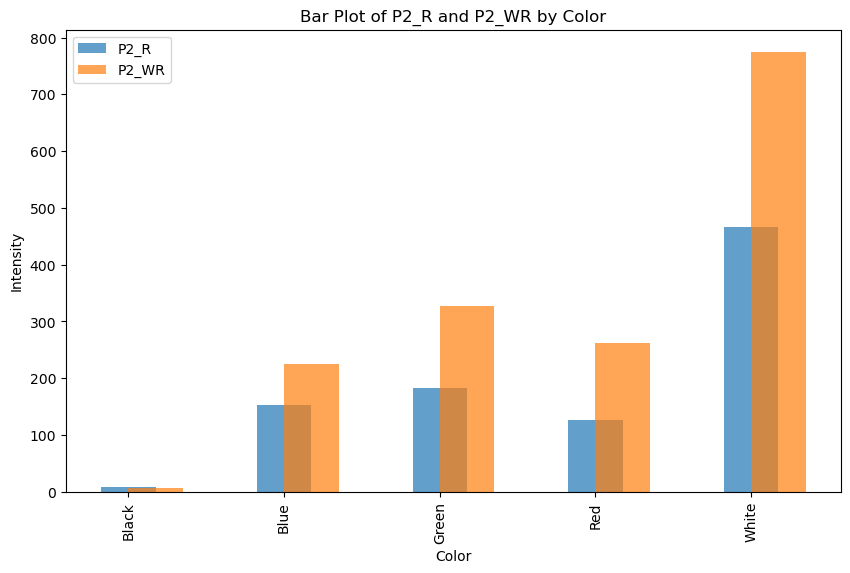

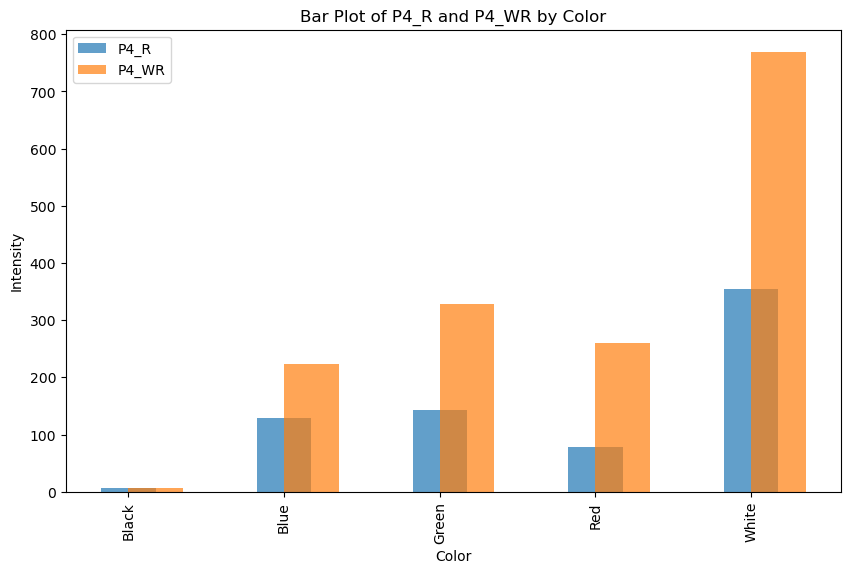

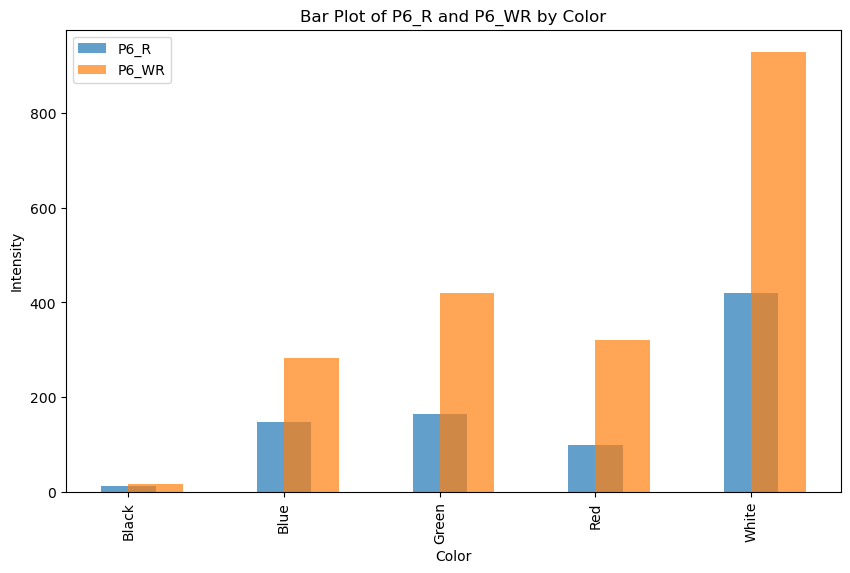

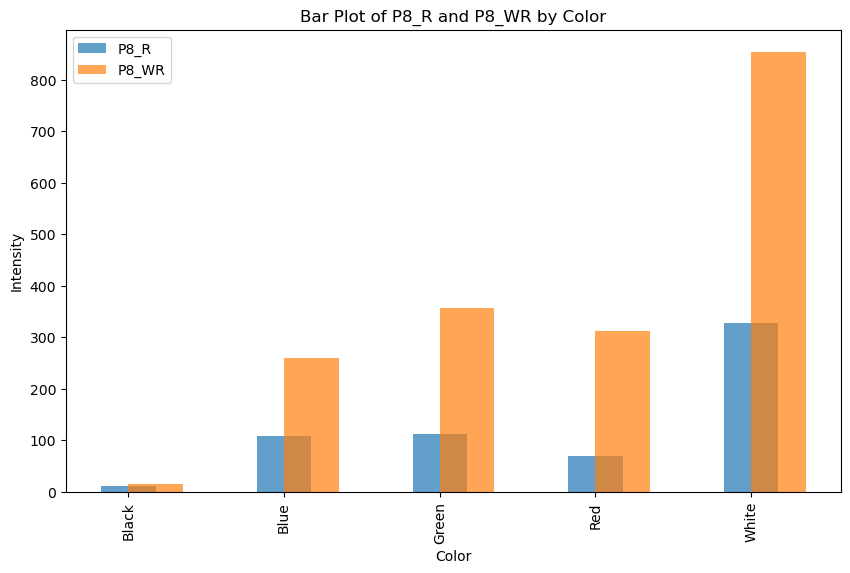

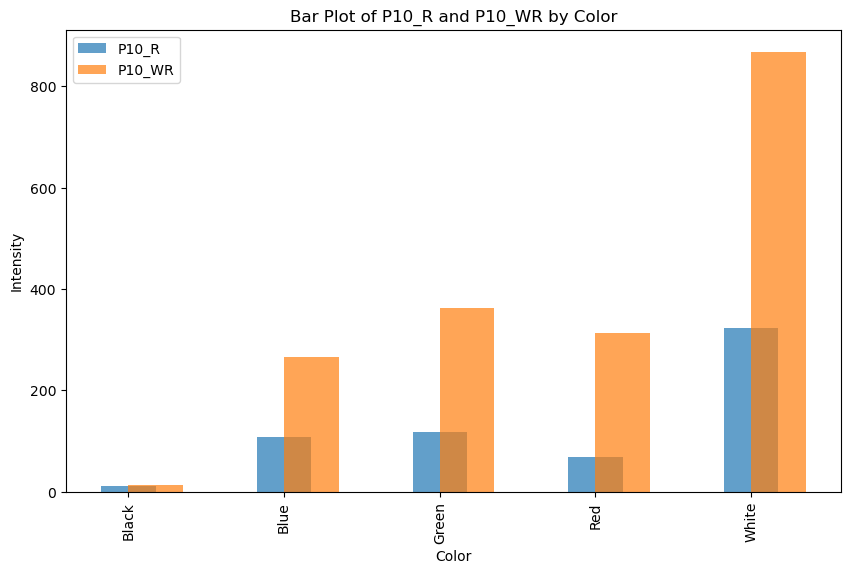

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Define the column pairs to plot
column_pairs = [("P2_R", "P2_WR"),("P4_R", "P4_WR"), ("P6_R", "P6_WR"), ("P8_R", "P8_WR"), ("P10_R", "P10_WR")]

# Set the width of the bars
bar_width = 0.35

# Get unique colors
colors = df["Color"].unique()

# Create a bar plot for each column pair
for col1, col2 in column_pairs:
    plt.figure(figsize=(10, 6))  # Create a new figure for each pair

    # Set "Color" column as the x-axis
    x = df["Color"]

    # Set the values of the two columns as the y-axis
    y1 = df[col1]
    y2 = df[col2]

    # Set the x positions for the bars
    x_indexes = range(len(x))

    # Plot the values as side-by-side bars
    plt.bar(x_indexes, y1, width=bar_width, label=col1, align="center", alpha=0.7)
    plt.bar(x_indexes, y2, width=bar_width, label=col2, align="edge", alpha=0.7)

    # Customize the plot
    plt.xlabel("Color")
    plt.ylabel("Intensity")
    plt.title(f"Bar Plot of {col1} and {col2} by Color")
    plt.xticks(x_indexes, x, rotation=90)
    plt.legend()

    # Show the plot
    plt.show()



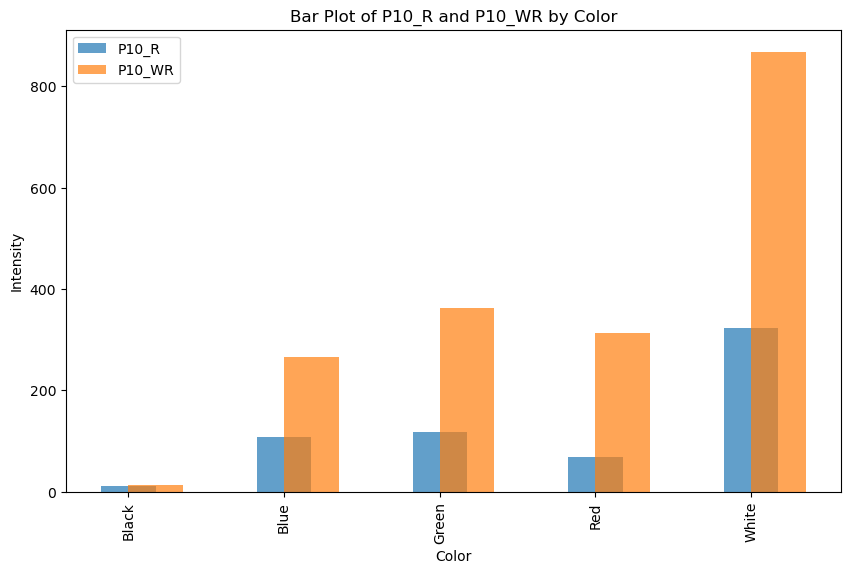

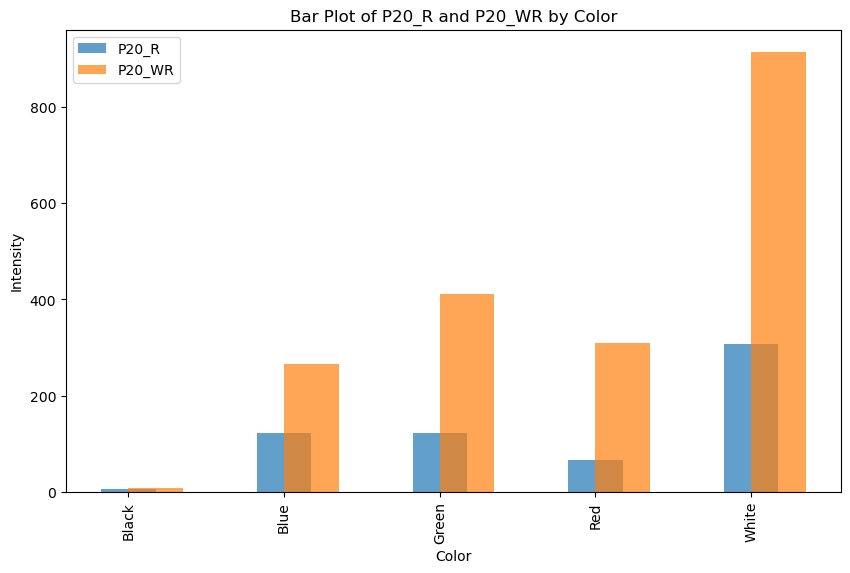

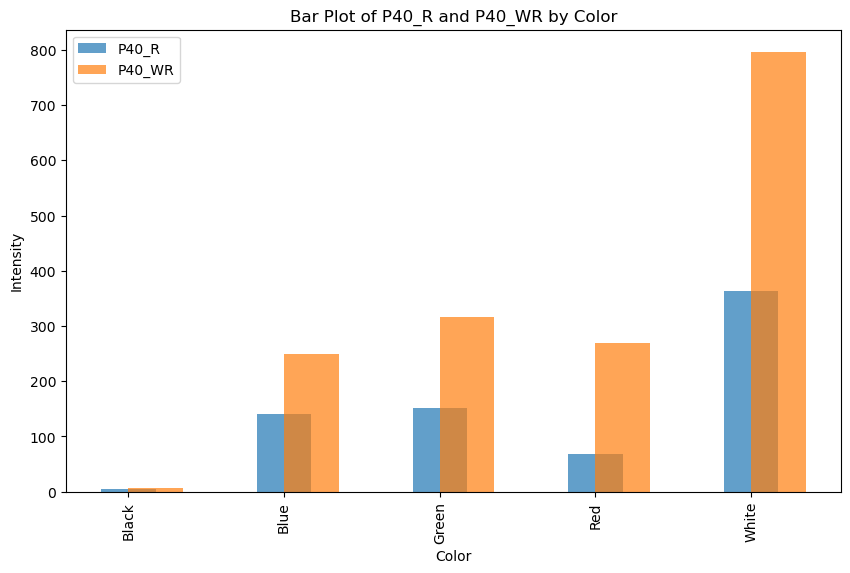

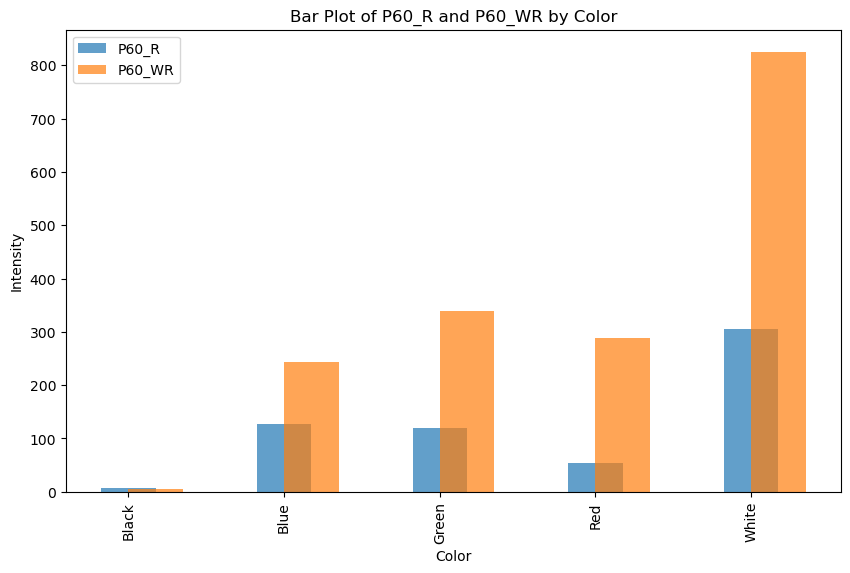

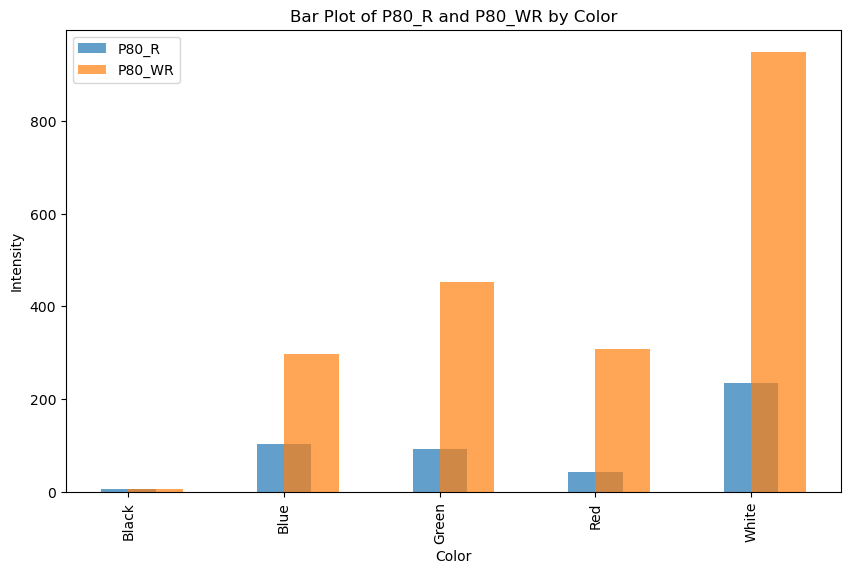

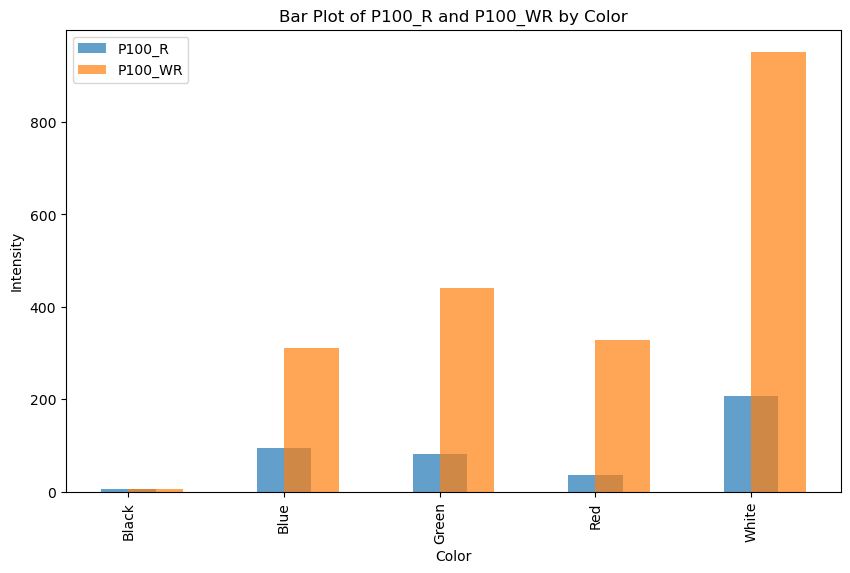

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/P_all_Mean.csv")

# Define the column pairs to plot
column_pairs = [("P10_R", "P10_WR"),("P20_R", "P20_WR"),("P40_R", "P40_WR"), ("P60_R", "P60_WR"), ("P80_R", "P80_WR"), ("P100_R", "P100_WR")]

# Set the width of the bars
bar_width = 0.35

# Get unique colors
colors = df["Color"].unique()

# Create a bar plot for each column pair
for col1, col2 in column_pairs:
    plt.figure(figsize=(10, 6))  # Create a new figure for each pair

    # Set "Color" column as the x-axis
    x = df["Color"]

    # Set the values of the two columns as the y-axis
    y1 = df[col1]
    y2 = df[col2]

    # Set the x positions for the bars
    x_indexes = range(len(x))

    # Plot the values as side-by-side bars
    plt.bar(x_indexes, y1, width=bar_width, label=col1, align="center", alpha=0.7)
    plt.bar(x_indexes, y2, width=bar_width, label=col2, align="edge", alpha=0.7)

    # Customize the plot
    plt.xlabel("Color")
    plt.ylabel("Intensity")
    plt.title(f"Bar Plot of {col1} and {col2} by Color")
    plt.xticks(x_indexes, x, rotation=90)
    plt.legend()

    # Show the plot
    plt.show()

